# Tutorial 4: Sweeps — Navigating Parameter Space

In Tutorial 3, we manually wrote a Python loop to test different window sizes
and plotted the resulting MI estimates. That approach works, but it is slow,
sequential, and requires boilerplate code for every parameter we want to test.

`mode='sweep'` is the library's principled solution. It accepts a
`sweep_grid` dictionary specifying the values to test for any combination
of parameters — whether they control the data processing (like `window_size`)
or the neural network architecture (like `hidden_dim`) — generates every
combination automatically, and runs them in parallel across CPU cores.

This tutorial covers three things:

1. **Sweeping physical parameters** (`window_size`) to confirm the timescale
   intuition from Tutorial 3.
2. **Sweeping model parameters** (`hidden_dim`, `embedding_dim`) to find an
   architecture that is expressive enough without being wasteful.
3. **Averaging over random seeds** using the `run_id` trick, and reading the
   sweep `dataframe` to identify the best configuration.

We continue using the autocorrelated dataset from Tutorial 3 throughout.

## 1. Setup

We regenerate the same autocorrelated data as Tutorial 3 for continuity.
`x_raw` and `y_raw` have shape `(n_timepoints, n_channels)` — timepoints first,
which is the convention required by the continuous processor (see Tutorial 2).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import neural_mi as nmi

sns.set_context("talk")
np.random.seed(42)

# Same data as Tutorial 3
n_timepoints = 5000
n_channels = 4
timescale = 50  # dominant autocorrelation timescale in samples

x_raw, y_raw = nmi.generators.generate_windowed_dependency_data(
    n_timepoints=n_timepoints,
    n_channels=n_channels,
    timescale=timescale,
    history_window=timescale,
    noise_level=0.3,
    use_torch=False
)

print(f"X shape: {x_raw.shape}  (n_timepoints, n_channels)")
print(f"Y shape: {y_raw.shape}  (n_timepoints, n_channels)")

X shape: (5000, 4)  (n_timepoints, n_channels)
Y shape: (5000, 4)  (n_timepoints, n_channels)


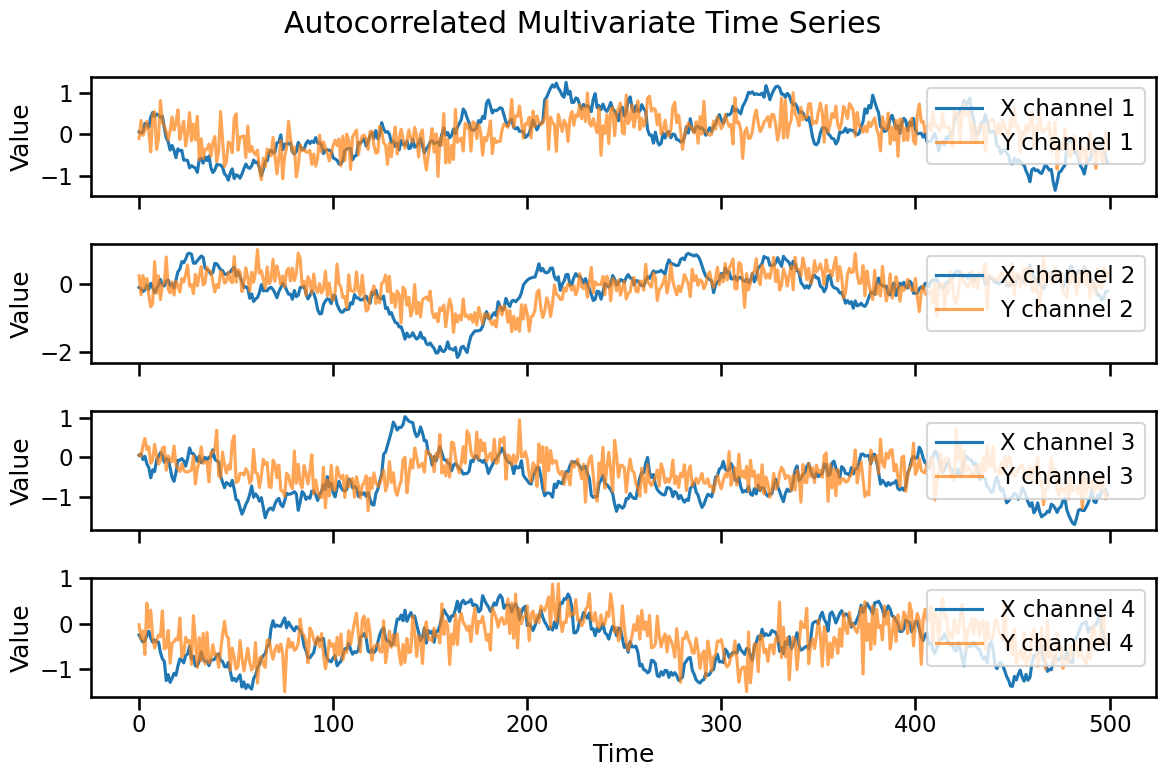

In [2]:
# plot the first 500 time points of each channel to visualize the autocorrelation
fig, axes = plt.subplots(n_channels, 1, figsize=(12, 8), sharex=True)
for i in range(n_channels):
    axes[i].plot(x_raw[:500, i], label=f"X channel {i+1}")
    axes[i].plot(y_raw[:500, i], label=f"Y channel {i+1}", alpha=0.7)
    axes[i].legend(loc="upper right")
    axes[i].set_ylabel("Value")
axes[-1].set_xlabel("Time")
plt.suptitle("Autocorrelated Multivariate Time Series")
plt.tight_layout()
plt.show()

## 2. Sweeping Physical Parameters: Window Size

In Tutorial 3, we wrote a manual loop over `window_size` values. Let's now
do the same thing properly using `mode='sweep'`.

The key insight is that **all parameters are sweepable through the same
`sweep_grid` dictionary** — whether they belong to the data processor
(like `window_size`) or to the neural network (like `hidden_dim`). The library
routes each parameter to the right place internally. You do not need to
distinguish between "data parameters" and "model parameters" when building
the grid.

We test seven window sizes ranging from very short (misses temporal structure)
to very long (too few samples). We use `Split(mode='blocked')` throughout —
as established in Tutorial 3, this is mandatory for any continuous recording.

In [3]:
training = nmi.Training(n_epochs=300, patience=50, learning_rate=1e-4)

window_sweep_grid = {
    'window_size': [10, 30, 50, 70, 100, 150, 200],
    'run_id': range(3),   # repeat each combination 3 times for stability
}

print("Sweeping window sizes — running 21 combinations (7 sizes × 3 seeds)...")
window_results = nmi.run(
    x_raw, y_raw,
    mode='sweep',
    sweep_grid=window_sweep_grid,
    processing=nmi.Processing(x='continuous', x_params={'step_size': 10},  # window_size comes from sweep_grid for some overlap to capture more temporal structure
                              y='continuous', y_params={'step_size': 10}),
    split=nmi.Split(mode='blocked'),   # CORRECT for time-series data
    training=training,
    n_workers=4,            # run combinations in parallel — set to your core count,
    show_progress=False,
)

Sweeping window sizes — running 21 combinations (7 sizes × 3 seeds)...


2026-07-14 05:35:07 - neural_mi - INFO - Window coverage: 500/500 windows have sufficient data
2026-07-14 05:35:07 - neural_mi - INFO - Window coverage: 500/500 windows have sufficient data
2026-07-14 05:35:07 - neural_mi - INFO - Created 500 aligned windows
2026-07-14 05:35:07 - neural_mi - INFO - Created 500 aligned windows
2026-07-14 05:35:07 - neural_mi - INFO - Window coverage: 500/500 windows have sufficient data
2026-07-14 05:35:07 - neural_mi - INFO - Created 500 aligned windows
2026-07-14 05:35:07 - neural_mi - INFO - Window coverage: 500/500 windows have sufficient data
2026-07-14 05:35:07 - neural_mi - INFO - Created 500 aligned windows


2026-07-14 05:35:14 - neural_mi - INFO - Window coverage: 500/500 windows have sufficient data
2026-07-14 05:35:14 - neural_mi - INFO - Created 500 aligned windows


2026-07-14 05:35:15 - neural_mi - INFO - Window coverage: 500/500 windows have sufficient data
2026-07-14 05:35:15 - neural_mi - INFO - Created 500 aligned windows


2026-07-14 05:35:15 - neural_mi - INFO - Window coverage: 499/500 windows have sufficient data
2026-07-14 05:35:15 - neural_mi - INFO - Created 499 aligned windows
2026-07-14 05:35:15 - neural_mi - INFO - Window coverage: 499/500 windows have sufficient data
2026-07-14 05:35:15 - neural_mi - INFO - Created 499 aligned windows


...

2026-07-14 05:35:32 - neural_mi - INFO - Window coverage: 497/500 windows have sufficient data
2026-07-14 05:35:32 - neural_mi - INFO - Created 497 aligned windows


2026-07-14 05:35:32 - neural_mi - INFO - Window coverage: 497/500 windows have sufficient data
2026-07-14 05:35:32 - neural_mi - INFO - Created 497 aligned windows


2026-07-14 05:35:33 - neural_mi - INFO - Window coverage: 496/500 windows have sufficient data
2026-07-14 05:35:33 - neural_mi - INFO - Created 496 aligned windows


2026-07-14 05:35:34 - neural_mi - INFO - Window coverage: 496/500 windows have sufficient data
2026-07-14 05:35:34 - neural_mi - INFO - Created 496 aligned windows


2026-07-14 05:35:36 - neural_mi - INFO - Window coverage: 496/500 windows have sufficient data
2026-07-14 05:35:36 - neural_mi - INFO - Created 496 aligned windows


`n_workers` maps directly to CPU or GPU cores used for parallelisation. Setting it
to 4 means 4 combinations run simultaneously. For a sweep with many
combinations, this is the single most effective way to reduce wall-clock time.
On a laptop, 2–4 is typical; on a server, 8–16 or more.

Note that full reproducibility (exact same numbers across runs) requires
`n_workers=1` with a fixed `seed`; with `n_workers > 1`, results will
be statistically consistent but not bit-identical across runs, because task
scheduling introduces non-determinism in the order floating-point operations
accumulate.

In [4]:
df_window = window_results.dataframe
print(df_window[['window_size', 'mi_mean', 'mi_std']].to_string(index=False))

 window_size  mi_mean   mi_std
          10 2.576582 0.153091
          30 4.156496 0.104379
          50 4.530477 0.462887
          70 5.004535 0.239838
         100 5.219623 0.080196
         150 5.011874 0.147909
         200 5.221115 0.228998


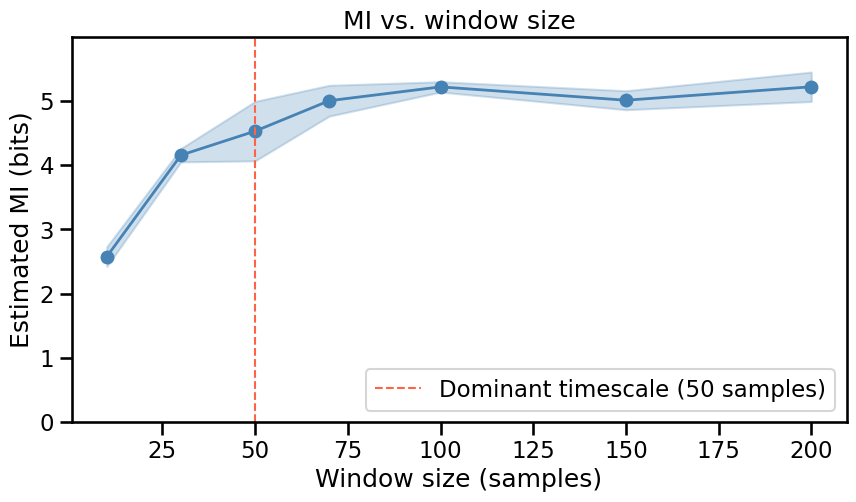

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_window['window_size'], df_window['mi_mean'],
        'o-', color='steelblue', linewidth=2)
ax.fill_between(df_window['window_size'],
                df_window['mi_mean'] - df_window['mi_std'],
                df_window['mi_mean'] + df_window['mi_std'],
                alpha=0.25, color='steelblue')
ax.axvline(timescale, linestyle='--', color='tomato', linewidth=1.5,
           label=f"Dominant timescale ({timescale} samples)")
ax.set_xlabel("Window size (samples)")
ax.set_ylabel("Estimated MI (bits)")
ax.set_title("MI vs. window size")
ax.legend()
plt.ylim(0, np.amax(df_window['mi_mean'] + df_window['mi_std']) * 1.1)
plt.show()

The curve reproduces what we found manually in Tutorial 3: MI rises steeply
for short windows, then hovers and fluctuates once the window is long enough to
capture the temporal structure — it does not settle on one value, and longer
windows carry fewer samples and so are noisier. The shaded error band, which
comes from the three repeated runs at each window size, gives us a measure of
estimator variance — how much the answer changes due to random initialisation
and data shuffling alone.

From this sweep we can identify a good `window_size` to use in subsequent
analyses: any value in the plateau region is valid. We will carry
`window_size=timescale` forward for the model parameter sweep below.

Now let us ask a different question: given a fixed window size, does the
neural network architecture matter?

## 3. Sweeping Model Parameters: Architecture Search

The MI estimator is a neural network critic. Its architecture — how wide and
deep it is, and how large the embedding vectors are — determines its capacity
to capture complex relationships in the data. An architecture that is too small
will underfit and underestimate MI; one that is too large may overfit or train
slowly without adding accuracy.

We sweep over two architecture parameters jointly:

- `hidden_dim`: the width of the hidden layers. Larger values give the network
  more capacity to learn complex mappings.
- `embedding_dim`: the size of the embedding vector that each input is mapped
  to before computing the MI score. This is also the **information bottleneck**
  — a key concept we return to in Tutorial 7 when estimating latent dimensionality.

A joint sweep tests every combination of the two parameters. With 3 values
for each and 3 repeated runs, this is $3 \times 3 \times 3 = 27$ combinations.
We use `n_workers=4` to run them in parallel.

In [6]:
model_sweep_grid = {
    'hidden_dim':    [8, 64, 256],
    'embedding_dim': [2, 16, 64],
    'run_id': range(3),  # repeat each combination 3 times for stability
}

# window_size is fixed here (not in sweep_grid), so data is pre-processed once
# and each worker only varies the model architecture.
print("Sweeping model parameters — running 27 combinations (3×3 grid, 3 seeds each)...")
model_results = nmi.run(
    x_raw, y_raw,
    mode='sweep',
    sweep_grid=model_sweep_grid,
    processing=nmi.Processing(x='continuous', x_params={'window_size': timescale, 'step_size': 10},  # fixed at plateau value
                              y='continuous', y_params={'window_size': timescale, 'step_size': 10}),
    split=nmi.Split(mode='blocked'),   # CORRECT for time-series data
    training=training,
    n_workers=4,
    show_progress=False,
)

Sweeping model parameters — running 27 combinations (3×3 grid, 3 seeds each)...


/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_91421/90794593.py:10: UserWarning: Small dataset detected (499 windows). Regularisation may help: consider adding dropout=0.1 and norm_layer='layer' to your Model config.
  model_results = nmi.run(


2026-07-14 05:35:45 - neural_mi - INFO - Created PairedDataset
2026-07-14 05:35:45 - neural_mi - INFO - Created PairedDataset
2026-07-14 05:35:45 - neural_mi - INFO - Created PairedDataset
2026-07-14 05:35:45 - neural_mi - INFO - Created PairedDataset


2026-07-14 05:35:51 - neural_mi - INFO - Created PairedDataset


2026-07-14 05:35:51 - neural_mi - INFO - Created PairedDataset


...

2026-07-14 05:36:19 - neural_mi - INFO - Created PairedDataset


2026-07-14 05:36:20 - neural_mi - INFO - Created PairedDataset


2026-07-14 05:36:20 - neural_mi - INFO - Created PairedDataset


2026-07-14 05:36:23 - neural_mi - INFO - Created PairedDataset


2026-07-14 05:36:23 - neural_mi - INFO - Created PairedDataset


In [7]:
df_model = model_results.dataframe
print(df_model[['hidden_dim', 'embedding_dim', 'mi_mean', 'mi_std']]
      .sort_values('mi_mean', ascending=False)
      .to_string(index=False))

 hidden_dim  embedding_dim  mi_mean   mi_std
        256             64 5.098278 0.265881
        256             16 5.079549 0.069459
         64             64 4.952791 0.109884
         64             16 4.446690 0.593986
          8             64 2.173824 0.946328
        256              2 1.919307 0.521542
         64              2 1.845080 0.437344
          8             16 1.675780 1.016004
          8              2 1.135496 0.871718


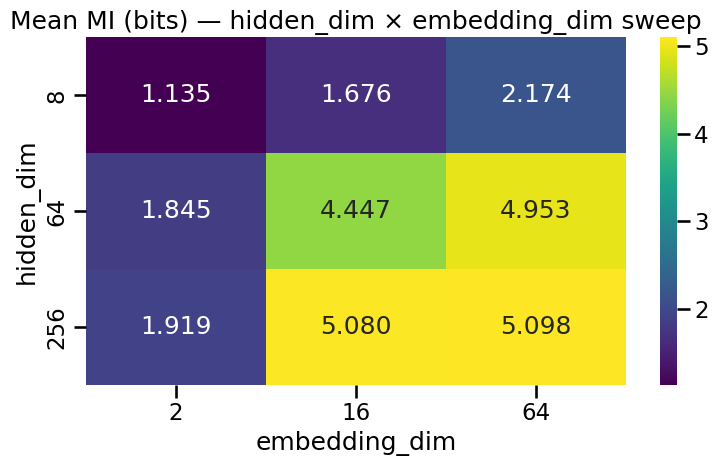

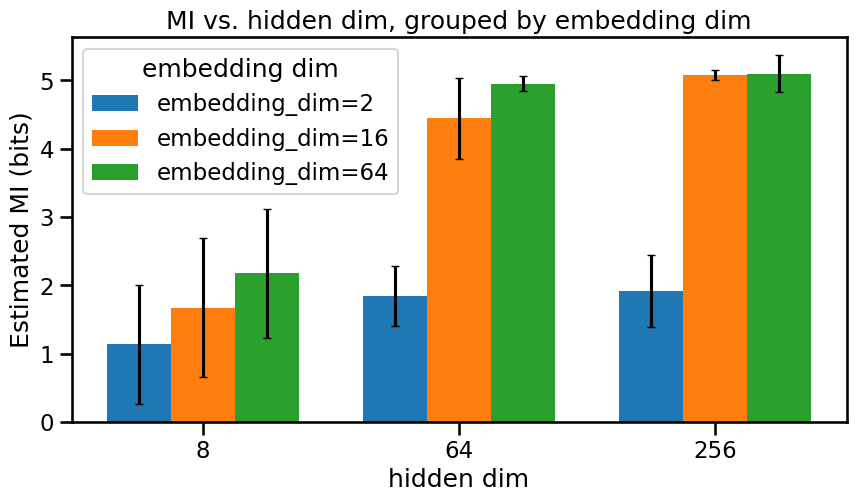

In [8]:
# Pivot to (hidden_dim × embedding_dim) matrix for the heatmap.
pivot = df_model.pivot_table(values='mi_mean', index='hidden_dim', columns='embedding_dim')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='viridis', ax=ax)
ax.set_title("Mean MI (bits) — hidden_dim × embedding_dim sweep")
ax.set_xlabel("embedding_dim")
ax.set_ylabel("hidden_dim")
plt.tight_layout()
plt.show()

# Grouped bar chart: MI vs hidden_dim, one bar group per embedding_dim.
fig, ax = plt.subplots(figsize=(10, 5))

# 1. Get unique categories and setup spacing
categories = sorted(df_model['hidden_dim'].unique())
embedding_dims = sorted(df_model['embedding_dim'].unique())

n_groups = len(categories)
n_hues = len(embedding_dims)

x = np.arange(n_groups)  # The label locations: [0, 1, 2...]
width = 0.25             # Width of individual bars

# 2. Plot each group with an offset
for i, embedding_dim in enumerate(embedding_dims):
    subset = df_model[df_model['embedding_dim'] == embedding_dim]
    
    # Calculate offset so bars are centered over the tick
    # (i - (total_hues - 1) / 2) centers the group
    offset = (i - (n_hues - 1) / 2) * width
    
    ax.bar(x + offset, subset['mi_mean'], width=width,
           label=f"embedding_dim={embedding_dim}", 
           yerr=subset['mi_std'], capsize=3)

# 3. Fix the X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.set_title("MI vs. hidden dim, grouped by embedding dim")
ax.set_xlabel("hidden dim")
ax.set_ylabel("Estimated MI (bits)")
ax.legend(title="embedding dim")

plt.show()


The heatmap reveals how architecture capacity affects the estimate. For this
dataset, MI should plateau once the network is expressive enough to capture
the relationship between $X$ and $Y$. Combinations that produce lower MI are
underfitting — the network is too small. Once the estimate plateaus, adding
more capacity does not help and only increases training time.

A practical rule: choose the **smallest architecture whose MI estimate has
plateaued**. There is no benefit to using a larger network if the estimate
is already stable, and a smaller network trains faster and is less likely
to overfit on limited data.

The error bars (from the three repeated `run_id` seeds) show estimator
variance. If the error bars are large relative to the differences between
architecture choices, the sweep is telling you that architecture matters
less than the noise in the estimator — and you should increase the number
of training epochs or the dataset size rather than searching for a better
architecture.

## 4. The `run_id` Trick and Estimator Variance

You may have noticed that we included `'run_id': range(3)` in every sweep
grid. This is not a real parameter — the library ignores its value. Its
purpose is to instruct the sweep engine to run each unique combination of
the *other* parameters three times, each time with a different random
initialisation.

The result is that `results.dataframe` contains three rows per parameter
combination, from which the library computes `mi_mean` and `mi_std`
automatically. The standard deviation across runs is a direct measure of
**estimator variance**: how much the answer changes due to randomness in
training rather than true differences in MI.

This matters for two reasons:

1. **Reliability.** If `mi_std` is large relative to `mi_mean`, a single
   run is not trustworthy. You should either increase `n_epochs`, increase
   dataset size, or use `mode='rigorous'` (Tutorial 5) which is designed
   precisely to handle this.

2. **Fair comparison.** When comparing two parameter combinations, you should
   compare their `mi_mean ± mi_std` intervals rather than single-run values.
   A difference that is smaller than the error bars is not meaningful.

**How many `run_id` repeats do you need?** Three is a practical minimum for
a sweep — enough to detect gross instability without tripling your compute
time. For a final, publication-quality estimate, use `mode='rigorous'`
instead of relying on `run_id` averaging.

In [9]:
# Access raw per-run results before averaging. The per-run MI column is
# 'train_mi' (the train-partition MI at the best epoch), not 'mi_mean' --
# that name only appears in the aggregated dataframe after averaging over run_id.
best_hidden = df_model.loc[df_model['mi_mean'].idxmax(), 'hidden_dim']
best_embed  = df_model.loc[df_model['mi_mean'].idxmax(), 'embedding_dim']

raw_df = model_results.details.get('raw_results', model_results.dataframe)
mask = (raw_df['hidden_dim'] == best_hidden) & (raw_df['embedding_dim'] == best_embed)
subset = raw_df[mask][['run_id', 'hidden_dim', 'embedding_dim', 'train_mi']]

print(f"Three independent runs for hidden_dim={best_hidden}, "
      f"embedding_dim={best_embed}:")
print(subset.to_string(index=False))
print(f"\nMean: {subset['train_mi'].mean():.3f} bits")
print(f"Std:  {subset['train_mi'].std():.3f} bits")

Three independent runs for hidden_dim=256, embedding_dim=64:
 run_id  hidden_dim  embedding_dim  train_mi
      0         256             64  5.263559
      1         256             64  4.791575
      2         256             64  5.239702

Mean: 5.098 bits
Std:  0.266 bits


## 5. Reading the Sweep Dataframe

Every `mode='sweep'` call returns a `Results` object whose `.dataframe`
attribute is a pandas DataFrame with one row per unique parameter combination
(after averaging over `run_id`). The columns always include the swept
parameter names plus `mi_mean` and `mi_std`.

Here are the most useful operations for extracting information from a sweep:

In [10]:
df = model_results.dataframe

# Find the best combination
best_row = df.loc[df['mi_mean'].idxmax()]
print("Best parameter combination:")
print(best_row[['hidden_dim', 'embedding_dim', 'mi_mean', 'mi_std']])

# Find all combinations within 1 std of the best (equally valid, cheaper)
threshold = best_row['mi_mean'] - best_row['mi_std']
good_combinations = df[df['mi_mean'] >= threshold].sort_values('mi_mean', ascending=False)
print(f"\nCombinations within 1 std of the best (mi >= {threshold:.3f} bits):")
print(good_combinations[['hidden_dim', 'embedding_dim', 'mi_mean', 'mi_std']]
      .to_string(index=False))

Best parameter combination:
hidden_dim       256.000000
embedding_dim     64.000000
mi_mean            5.098278
mi_std             0.265881
Name: 8, dtype: float64

Combinations within 1 std of the best (mi >= 4.832 bits):
 hidden_dim  embedding_dim  mi_mean   mi_std
        256             64 5.098278 0.265881
        256             16 5.079549 0.069459
         64             64 4.952791 0.109884


The "within 1 std of the best" query is particularly useful: it gives you
all architectures that are statistically indistinguishable from the best one.
Among these, prefer the smallest (lowest `hidden_dim` and `embedding_dim`)
for speed and reduced overfitting risk.

This is the practical workflow before any rigorous analysis:
1. Sweep `window_size` to find the plateau region.
2. Sweep `hidden_dim` and `embedding_dim` to find the smallest sufficient
   architecture.
3. Use those parameters in `mode='rigorous'` for the final, bias-corrected
   estimate — the subject of **Tutorial 5**.

## 6. Key Takeaways

- **`mode='sweep'` automates parameter search.** Pass a `sweep_grid` dictionary
  with lists of values for any parameters — physical (like `window_size`) or
  architectural (like `hidden_dim`). The library generates every combination and
  runs them, optionally in parallel.

- **All parameters are sweepable through the same interface.** Processor
  parameters like `window_size` and model parameters like `embedding_dim` both
  go into `sweep_grid`. The library routes them correctly.

- **`n_workers` is the most effective lever for speed.** Set it to the number
  of CPU cores available. With 4 workers, a 27-combination sweep runs in roughly
  one quarter of the sequential time.

- **`'run_id': range(N)` repeats each combination N times** with different
  random initialisations, giving `mi_mean` and `mi_std` per combination.
  Three repeats is a practical minimum; more is better for noisy estimators.

- **Choose the smallest architecture whose estimate has plateaued.** More
  capacity beyond the plateau does not improve accuracy and only increases
  training cost and overfitting risk.

- **The sweep dataframe is a pandas DataFrame.** Use standard pandas operations
  to find the best combination, filter by threshold, and compare conditions.

## Common Mistakes

1. **Sweeping with `n_workers=1` on a large grid.** Sequential sweeps over many
   combinations can take hours. Always set `n_workers` to at least the number
   of physical cores on your machine when running a sweep. The one exception is
   when you need exact reproducibility — in that case, use `n_workers=1` with
   a fixed `seed`.

2. **Forgetting `x_params={}` in `Processing` when sweeping `window_size`.**
   If `window_size` is in `sweep_grid`, the processor's `x_params` dict should be
   empty (`{}`), not omitted, so the swept value is the one that is actually used.
   Omitting it may cause the library to fall back to a default `window_size` that
   conflicts with the sweep.

3. **Choosing the architecture with the highest single-run MI.**
   A single run with high MI might be a lucky initialisation rather than a
   genuinely better architecture. Always use `run_id` averaging and compare
   `mi_mean ± mi_std` across combinations.

4. **Treating sweep results as final estimates.** A sweep gives you a fast,
   exploratory estimate for each parameter combination. It is not bias-corrected.
   Use `mode='rigorous'` (Tutorial 5) with the best parameters found here for
   any result you intend to report.

## What's Next

We now know how to find good parameters systematically. But even with the
right parameters, a single MI estimate is not sufficient for rigorous science:
it has no error bar, and it is subject to finite-sample bias that makes a single value unreliable.
**Tutorial 5** introduces `mode='rigorous'`, which corrects for finite-sample
bias automatically and produces a bias-corrected estimate with a confidence
interval — the result you can report in a paper.